In [58]:
import numpy as np

results = np.load("data_Gauss/results_run.npy", allow_pickle=True).item()

Us = results['vec_U']
n_photons = results['vec_n_photon']
phases = results['vec_phase']
gammas = results['gammas']

print(f"U: {Us}")
print(f"n_photon: {n_photons}")
print(f"phases: {phases}")
print(f"gammas: {gammas}")

pulse_rate = 100 * 10 ** 6 # Hz, 1/s
wavelength = 0.800 # um
hbar_ueV_ps = 6.582e2 # ueV * ps
c = 300 # um / ps: vacuum speed of light
eV_to_Joule = 1.6022e-19 # Joule / eV

energy_per_photon = hbar_ueV_ps * c * (2*np.pi) / wavelength / 10**6 # eV

laser_powers = n_photons * energy_per_photon * pulse_rate * eV_to_Joule
print(f"\nlaser powers: {laser_powers}")

U: [0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1]
n_photon: [  1.           1.09854114   1.20679264   1.32571137   1.45634848
   1.59985872   1.75751062   1.93069773   2.12095089   2.32995181
   2.55954792   2.8117687    3.0888436    3.39322177   3.72759372
   4.09491506   4.49843267   4.94171336   5.42867544   5.96362332
   6.55128557   7.19685673   7.90604321   8.68511374   9.54095476
  10.48113134  11.51395399  12.64855217  13.89495494  15.26417967
  16.76832937  18.42069969  20.23589648  22.22996483  24.42053095
  26.82695795  29.47051703  32.37457543  35.56480306  39.06939937
  42.9193426   47.14866363  51.79474679  56.89866029  62.50551925
  68.6648845   75.43120063  82.86427729  91.0298178  100.        ]
phases: [0.03141593 0.04468043 0.05794493 0.07120943 0.08447394 0.09773844
 0.11100294 0.12426744 0.13753195 0.15079645 0.16406095 0.17732545
 0.19058995 0.20385446 0.21711896 0.23038346 0.24364796 0.25691247
 0.27017697 0.28344147 0.29670597 0.30997048 0.32323498 0.33649948
 0.34

# $n_S$ plot

 (U,gamma): (0.01, 0.0)
 (U,gamma): (0.05, 0.0)


/home/vanregem/projects/tensor-circuit-torch/MPDO_circuit/.venv/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/vanregem/projects/tensor-circuit-torch/MPDO_circuit/.venv/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


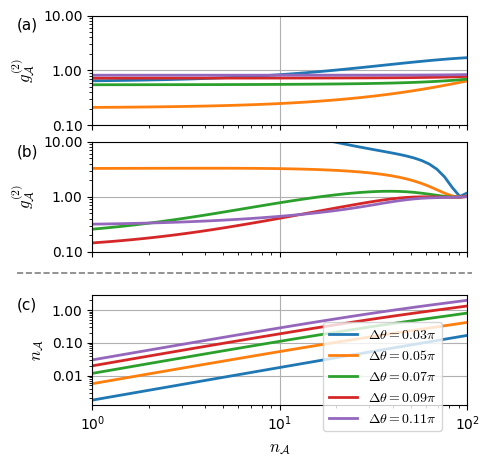

In [66]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from itertools import product

import matplotlib as mpl
mpl.rcParams['text.usetex'] = False
mpl.rcParams['mathtext.fontset'] = 'cm'

vec_U = [0.01, 0.05]
vec_gamma = [0.]
vec_phase = phases[4:-20:5]

n_photon_plot = n_photons

num_panel = len(vec_U) + 1

fig, ax = plt.subplots(num_panel, 1, figsize=(5, 1.5*num_panel), sharex=True)

for i, (U, gamma) in enumerate(product(vec_U, vec_gamma)):

    print(f" (U,gamma): {(U, gamma)}")
    for phase in vec_phase:
        dat_g2 = []
        dat_na = []
        for n_photon in n_photons:
            dat_na.append(results[(U, n_photon, phase, gamma)]['na'])
            dat_g2.append(results[(U, n_photon, phase, gamma)]['g2'])

        ax[i].loglog(n_photon_plot, dat_g2, "-", label=rf"$\Delta\theta={phase/np.pi:.2f}\pi$", linewidth=2)

        if i == 0:
            ax[-1].loglog(n_photon_plot, dat_na, "-", label=rf"$\Delta\theta={phase/np.pi:.2f}\pi$", linewidth=2)

ax[-1].legend(fontsize=10, loc='lower right', bbox_to_anchor=(.95, -0.3))
ax[-1].set_xlabel(r"$n_\mathcal{A}$", fontsize=12)

for a, label in zip(ax, ['(a)', '(b)', '(c)']):
    a.text(-0.2, 0.98, label, transform=a.transAxes,
           fontsize=11, fontweight='normal', va='top', ha='left')
    a.set_xlim([np.min(n_photon_plot), np.max(n_photon_plot)])
    a.grid(True)
    a.yaxis.set_major_formatter(ScalarFormatter())
    #a.yaxis.set_minor_formatter(ScalarFormatter())

for a in ax[:2]:
    a.set_ylabel(r"$g^{(2)}_\mathcal{A}$", fontsize=12)
    a.set_ylim([0.1, 10])

ax[2].set_ylabel(r"$n_\mathcal{A}$", fontsize=12)

fig.tight_layout()

# Add extra space between ax[1] and ax[2]
fig.subplots_adjust(hspace=0.15)  # first set a uniform baseline
pos0 = ax[0].get_position()
pos1 = ax[1].get_position()
pos2 = ax[2].get_position()

gap_extra = 0.06  # extra vertical gap between ax[1] and ax[2]

ax[0].set_position([pos0.x0, pos0.y0 + gap_extra, pos0.width, pos0.height])
ax[1].set_position([pos1.x0, pos1.y0 + gap_extra, pos1.width, pos1.height])

# Draw dotted line in figure coordinates between ax[1] and ax[2]
pos1_updated = ax[1].get_position()
pos2_updated = ax[2].get_position()

y_line = (pos1_updated.y0 + pos2_updated.y1) / 2  # midpoint of the gap
x0_line = pos1_updated.x0 - .15
x1_line = pos1_updated.x1 + 0.01

fig.add_artist(plt.Line2D(
    [x0_line, x1_line], [y_line, y_line],
    transform=fig.transFigure,
    color='gray',
    linestyle='--',
    linewidth=1.2,
    clip_on=False
))

fig.show()

# phase plot

 (U,gamma): (0.01, 0.0)
 (U,gamma): (0.05, 0.0)


/home/vanregem/projects/tensor-circuit-torch/MPDO_circuit/.venv/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/vanregem/projects/tensor-circuit-torch/MPDO_circuit/.venv/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


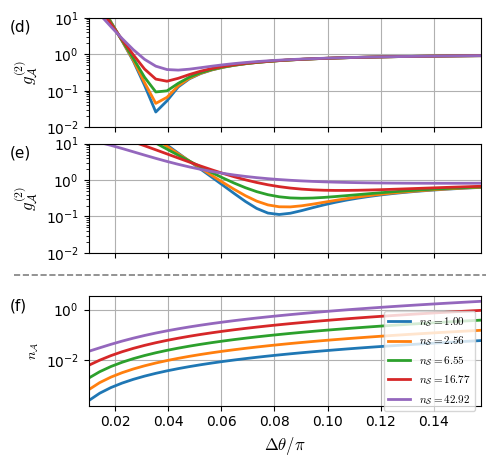

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from itertools import product

import matplotlib as mpl
mpl.rcParams['text.usetex'] = False
mpl.rcParams['mathtext.fontset'] = 'cm'

vec_U = [0.01, 0.05]
vec_gamma = [0.]
vec_n_photon = n_photons[0:-1:10]

phase_plot = phases[0:-10]

num_panel = len(vec_U) + 1  # +1 for dat_na panel
xaxis = phase_plot / np.pi

fig, ax = plt.subplots(num_panel, 1, figsize=(5, 1.5*num_panel), sharex=True)

for i, (U, gamma) in enumerate(product(vec_U, vec_gamma)):

    print(f" (U,gamma): {(U, gamma)}")
    for n_photon in vec_n_photon:
        dat_g2 = []
        dat_na = []
        for phase in phase_plot:
            dat_na.append(results[(U, n_photon, phase, gamma)]['na'])
            dat_g2.append(results[(U, n_photon, phase, gamma)]['g2'])

        ax[i].semilogy(xaxis, dat_g2, "-", label=rf"$n_\mathcal{{S}}={n_photon:.2f}$", linewidth=2)

        if i == 0:
            ax[-1].semilogy(xaxis, dat_na, "-", label=rf"$n_\mathcal{{S}}={n_photon:.2f}$", linewidth=2)

ax[-1].legend(fontsize=8, loc='lower right', bbox_to_anchor=(1., -0.1))
ax[-1].set_xlabel(r"$\Delta\theta/\pi$", fontsize=12)

for a, label in zip(ax, ['(d)', '(e)', '(f)']):
    a.text(-0.2, 0.98, label, transform=a.transAxes,
           fontsize=11, fontweight='normal', va='top', ha='left')
    a.set_xlim([np.min(xaxis), np.max(xaxis)])
    a.grid(True)
    a.xaxis.set_major_formatter(ScalarFormatter())
    a.xaxis.set_minor_formatter(ScalarFormatter())

for a in ax[:2]:
    a.set_ylabel(r"$g^{(2)}_\mathcal{A}$", fontsize=12)
    a.set_ylim([0.01, 10])

ax[2].set_ylabel(r"$n_\mathcal{A}$", fontsize=12)

fig.tight_layout()

# Add extra space between ax[1] and ax[2]
fig.subplots_adjust(hspace=0.15)
pos0 = ax[0].get_position()
pos1 = ax[1].get_position()

gap_extra = 0.06

ax[0].set_position([pos0.x0, pos0.y0 + gap_extra, pos0.width, pos0.height])
ax[1].set_position([pos1.x0, pos1.y0 + gap_extra, pos1.width, pos1.height])

# Draw dotted line between ax[1] and ax[2]
pos1_updated = ax[1].get_position()
pos2_updated = ax[2].get_position()

y_line = (pos1_updated.y0 + pos2_updated.y1) / 2
x0_line = pos1_updated.x0 - 0.15
x1_line = pos1_updated.x1 + 0.01

fig.add_artist(plt.Line2D(
    [x0_line, x1_line], [y_line, y_line],
    transform=fig.transFigure,
    color='gray',
    linestyle='--',
    linewidth=1.2,
    clip_on=False
))

fig.show()

 (U,gamma): (0.01, 0.0)
 (U,gamma): (0.05, 0.0)


/home/vanregem/projects/tensor-circuit-torch/MPDO_circuit/.venv/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/vanregem/projects/tensor-circuit-torch/MPDO_circuit/.venv/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


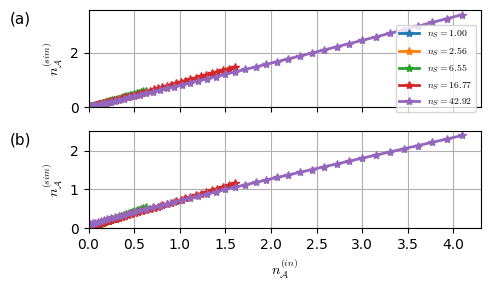

<Figure size 500x200 with 0 Axes>

<Figure size 500x200 with 0 Axes>

In [62]:
import matplotlib.pyplot as plt
from itertools import product

import matplotlib as mpl
mpl.rcParams['text.usetex'] = False
mpl.rcParams['mathtext.fontset'] = 'cm'

vec_U = [0.01, 0.05]
vec_gamma = [0.]
vec_n_photon = n_photons[0:-1:10]
#vec_nss = [nss[-10]]

phase_plot = phases[0:]

num_panel = len(vec_U)

fig, ax = plt.subplots(num_panel, 1, figsize=(5,1.5*num_panel), sharex=True)

for i, (U, gamma) in enumerate(product(vec_U, vec_gamma)):

    print(f" (U,gamma): {(U, gamma)}")
    plt.figure(figsize=(5,2))
    for n_photon in vec_n_photon:
        dat_g2 = []
        dat_n_photon = []
        dat_na = []
        dat_N = []
        for phase in phase_plot:
            dat_n_photon.append(results[(U, n_photon, phase, gamma)]['n_photon'])
            dat_na.append(results[(U, n_photon, phase, gamma)]['na'])
            dat_g2.append(results[(U, n_photon, phase, gamma)]['g2'])
            dat_N.append(results[(U, n_photon, phase, gamma)]['N'])

        #plt.loglog(nss, dat_n, ":", label=rf"$\theta/\pi={phase/np.pi:.2f}$")
        #x = 0.25 * phase_plot ** 2 * ns
        x = n_photon / 4 * np.abs(np.exp(1j * phase_plot) - 1.) ** 2
        ax[i].plot(x, dat_na, "-*", label=rf"$n_S={n_photon:.2f}$", linewidth=2)
        #ax[i].plot(x, dat_N, "o--", label=rf"$n_S={ns:.2f}$", linewidth=1)

ax[0].legend(fontsize=7, loc='lower right', bbox_to_anchor=(1., -0.1))
ax[1].set_xlabel(r"$n_\mathcal{A}^{(in)}$")

for a, label in zip(ax, ['(a)', '(b)']):
    a.text(-0.2, 0.98, label, transform=a.transAxes,
           fontsize=11, fontweight='normal', va='top', ha='left')
    #a.set_xlim([np.min(phase_plot), np.max(phase_plot)])
    a.set_xlim([0,None])
    a.set_ylim([0,None])
    a.grid(True)
    a.set_ylabel(r"$n_\mathcal{A}^{(sim)}$")

fig.tight_layout()
fig.show()

In [52]:
results[(U, n_photon, phase, gamma)]['n_photon']

np.float64(100.0)

In [217]:
U = 0.01
n_photon = n_photons[-1]
phase = phases[-1]
gamma = 0.

ns = results[(U, n_photon, phase, gamma)]['ns']
na = results[(U, n_photon, phase, gamma)]['na']

print(n_photon)
print(ns + na)

100.0
(96.8889079530457+0j)


 (n,gamma): (np.float64(0.031415926535897934), 0.0)
 (n,gamma): (np.float64(0.04468042885105484), 0.0)
 (n,gamma): (np.float64(0.05794493116621174), 0.0)
 (n,gamma): (np.float64(0.07120943348136866), 0.0)
 (n,gamma): (np.float64(0.08447393579652555), 0.0)
 (n,gamma): (np.float64(0.09773843811168247), 0.0)
 (n,gamma): (np.float64(0.11100294042683936), 0.0)
 (n,gamma): (np.float64(0.12426744274199628), 0.0)
 (n,gamma): (np.float64(0.1375319450571532), 0.0)
 (n,gamma): (np.float64(0.1507964473723101), 0.0)
 (n,gamma): (np.float64(0.164060949687467), 0.0)
 (n,gamma): (np.float64(0.1773254520026239), 0.0)
 (n,gamma): (np.float64(0.1905899543177808), 0.0)
 (n,gamma): (np.float64(0.20385445663293772), 0.0)
 (n,gamma): (np.float64(0.21711895894809458), 0.0)
 (n,gamma): (np.float64(0.2303834612632515), 0.0)
 (n,gamma): (np.float64(0.2436479635784084), 0.0)
 (n,gamma): (np.float64(0.2569124658935653), 0.0)
 (n,gamma): (np.float64(0.2701769682087222), 0.0)
 (n,gamma): (np.float64(0.28344147052387

/tmp/ipykernel_149898/3190517483.py:11: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(5,2))


 (n,gamma): (np.float64(0.3232349774693498), 0.0)
 (n,gamma): (np.float64(0.3364994797845067), 0.0)
 (n,gamma): (np.float64(0.34976398209966364), 0.0)
 (n,gamma): (np.float64(0.36302848441482055), 0.0)
 (n,gamma): (np.float64(0.37629298672997746), 0.0)
 (n,gamma): (np.float64(0.3895574890451344), 0.0)
 (n,gamma): (np.float64(0.4028219913602913), 0.0)
 (n,gamma): (np.float64(0.41608649367544814), 0.0)
 (n,gamma): (np.float64(0.4293509959906051), 0.0)
 (n,gamma): (np.float64(0.4426154983057621), 0.0)
 (n,gamma): (np.float64(0.45588000062091893), 0.0)
 (n,gamma): (np.float64(0.4691445029360758), 0.0)
 (n,gamma): (np.float64(0.48240900525123276), 0.0)
 (n,gamma): (np.float64(0.4956735075663896), 0.0)
 (n,gamma): (np.float64(0.5089380098815466), 0.0)
 (n,gamma): (np.float64(0.5222025121967034), 0.0)
 (n,gamma): (np.float64(0.5354670145118604), 0.0)
 (n,gamma): (np.float64(0.5487315168270173), 0.0)
 (n,gamma): (np.float64(0.5619960191421742), 0.0)
 (n,gamma): (np.float64(0.5752605214573311),

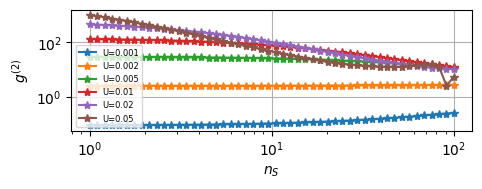

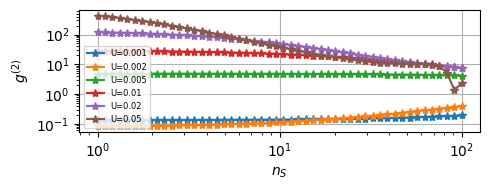

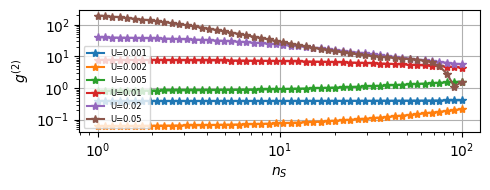

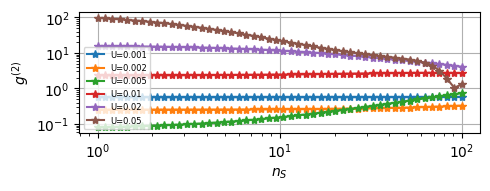

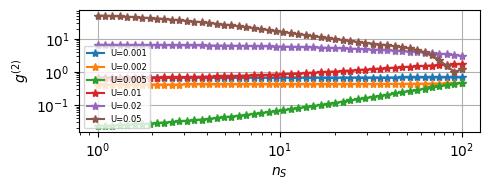

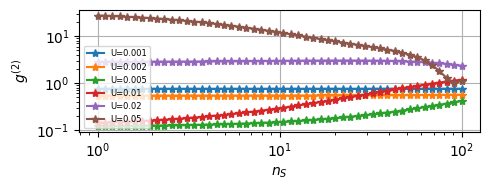

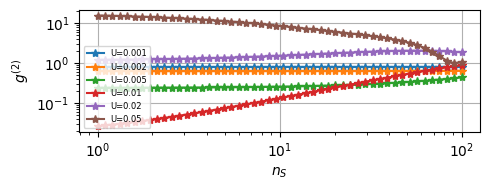

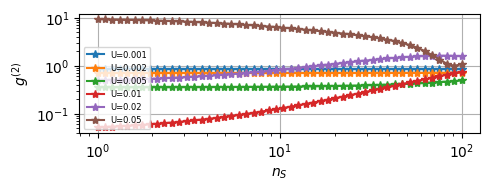

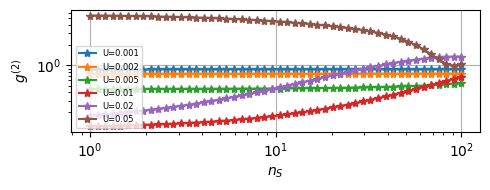

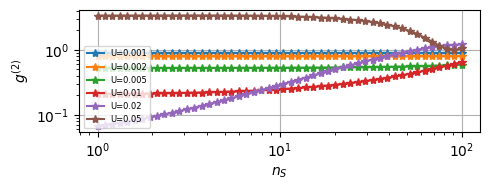

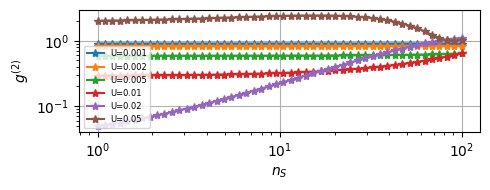

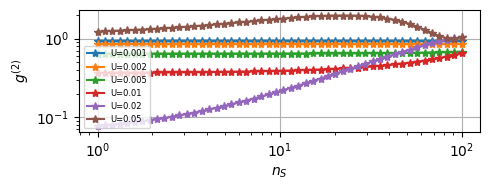

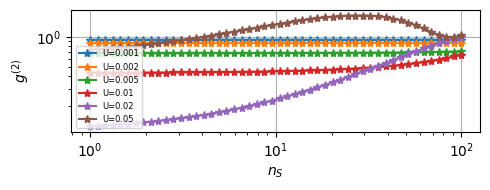

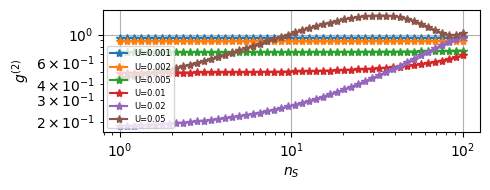

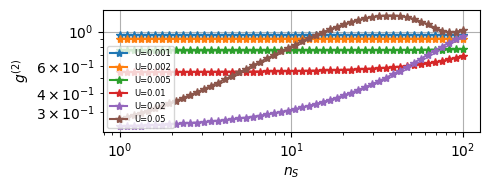

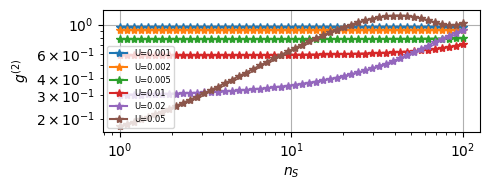

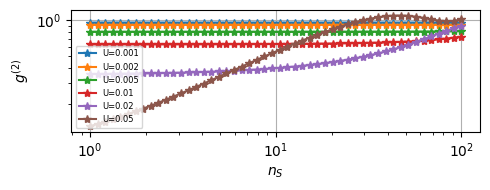

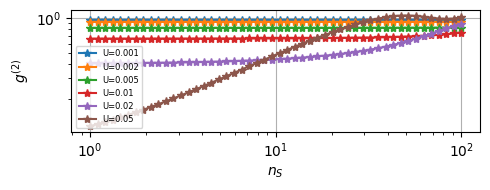

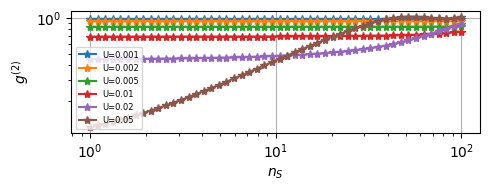

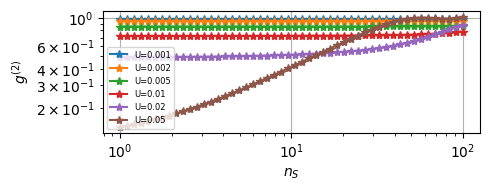

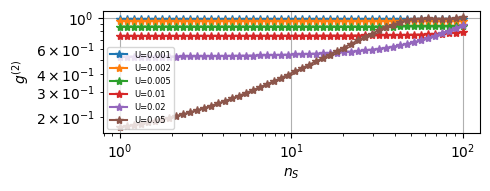

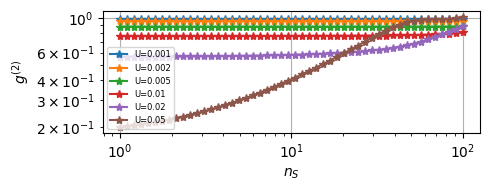

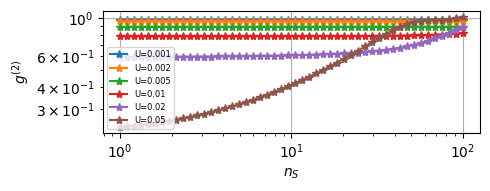

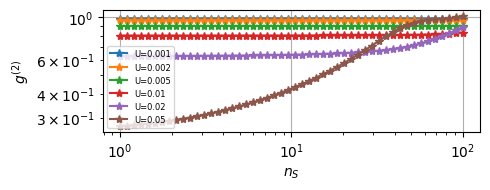

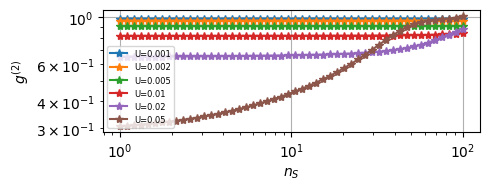

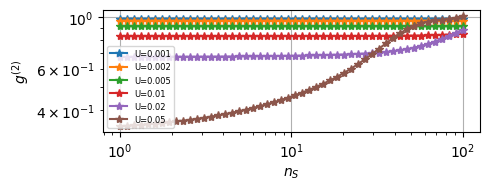

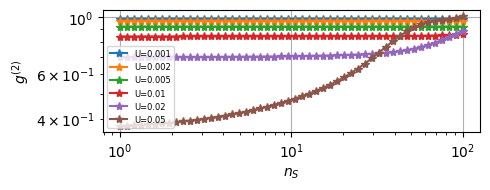

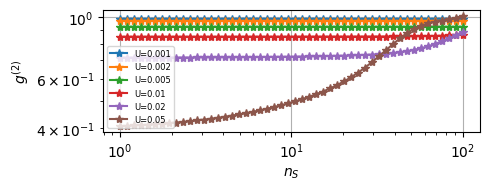

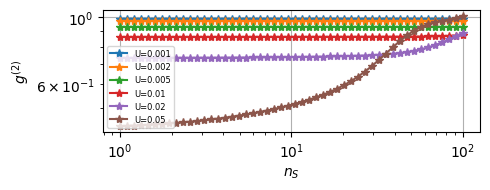

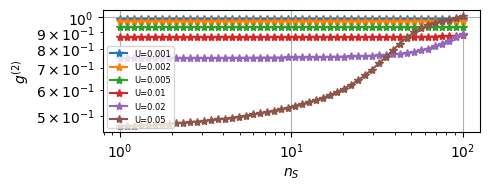

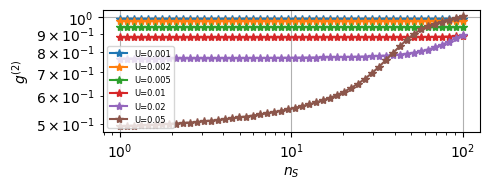

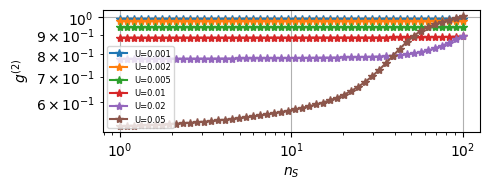

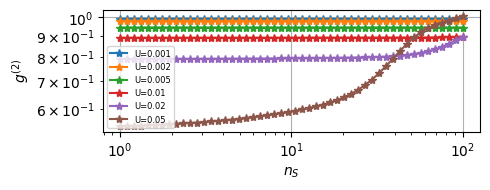

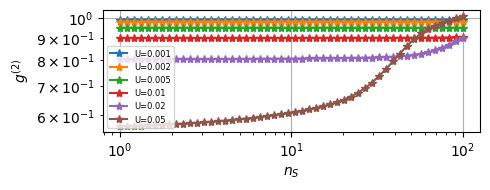

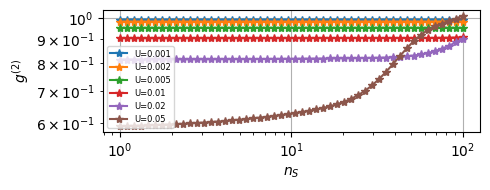

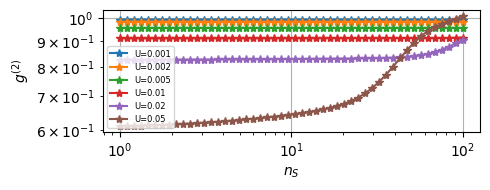

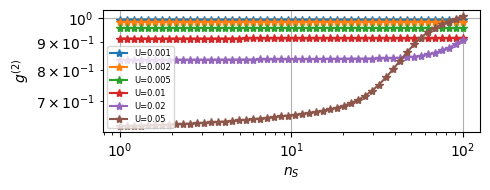

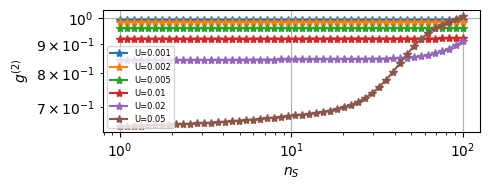

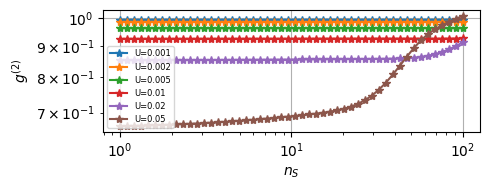

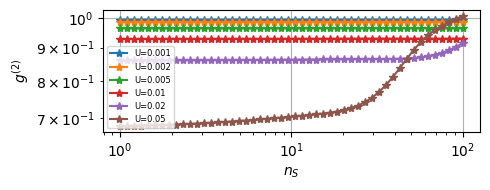

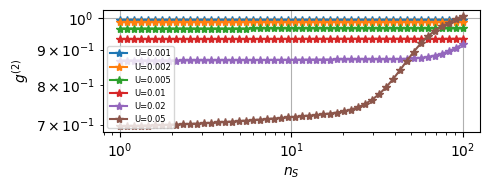

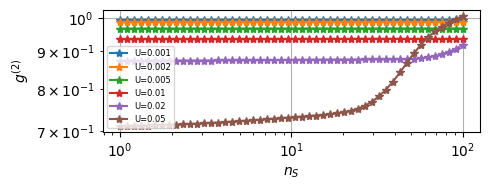

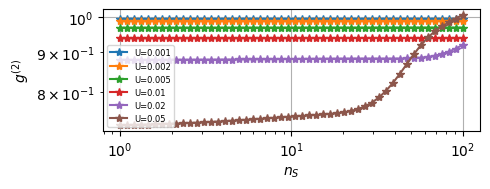

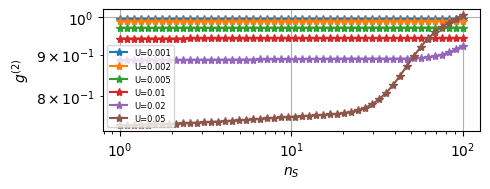

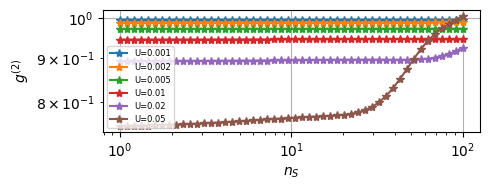

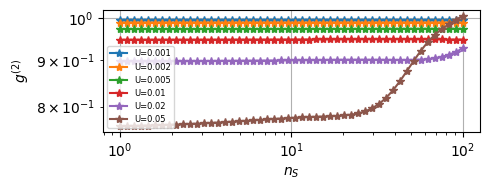

In [ ]:
import matplotlib.pyplot as plt
from itertools import product

phase_vec = phases
vec_gamma = [0.]


for (n_out_tar, gamma) in product(phases, vec_gamma):

    print(f" (n,gamma): {(n_out_tar, gamma)}")
    plt.figure(figsize=(5,2))
    for U in Us[:-1]:
        dat_g2 = []
        for n_photon in n_photons:
            dat_g2.append(results[(U, n_photon, n_out_tar, gamma)]['g2'])

        plt.loglog(n_photons, dat_g2, "*-", label=f"U={U}")

    #plt.ylim(0,0.3)
    plt.grid(True)
    plt.legend(fontsize=6, loc='lower left')
    plt.ylabel(r"$g^{(2)}$")
    plt.xlabel(r"$n_S$")
    # plt.ylim([0.02,1.1])
    plt.tight_layout()

# Dependence nonlinearity

# analyze resilience

In [3]:
from scipy.integrate import solve_ivp

def get_g2(alpha, N, M):
    n_alpha = np.abs(alpha) ** 2

    numerator = (
        n_alpha ** 2
        + 4 * N * n_alpha
        + M * alpha.conj() ** 2
        + M.conj() * alpha ** 2
        + 2 * N ** 2
        + M * M.conj()
    )
    denominator = n_alpha ** 2 + 2 * N * n_alpha + N ** 2
    g2 = numerator / denominator

    return g2.real

def solve_ODE_AS_mode(
    J, 
    U_ns, 
    alpha_0, 
    tlist, 
    Delta=0.,
    gamma=0.
    ):

  def dF(t, v):

    # extract alpha, N, M from vector
    alpha, N, M = v[0], v[1], v[2]

    # compute differentials
    d_alpha = (-gamma/2. - 1j*Delta) * alpha \
        -2j * J * alpha - 1j * 0.5 * U_ns * alpha - 1j * 0.5 * U_ns * alpha.conj()
    d_N = -gamma * N - U_ns * M.imag
    d_M = (-gamma - 2j*Delta) * M \
        -4j * J * M - 1j * U_ns * M - 1j * U_ns * (N + 0.5)

    # return differentials in array format
    return np.array([d_alpha, d_N, d_M])

  # solve the system, with right initial state
  y0 = np.array([alpha_0, 0, 0])
  sol = solve_ivp(dF, [tlist[0], tlist[-1]], y0=y0, t_eval=tlist)

  # return alpha, N, M tuple
  return sol.y[0], sol.y[1], sol.y[2]

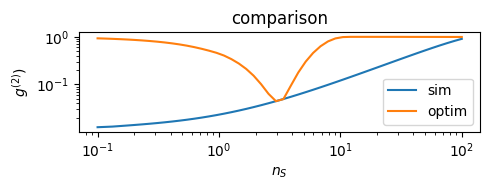

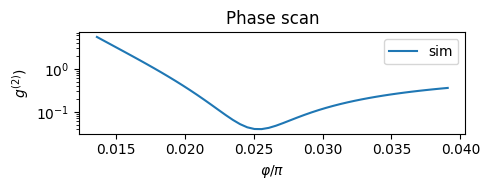

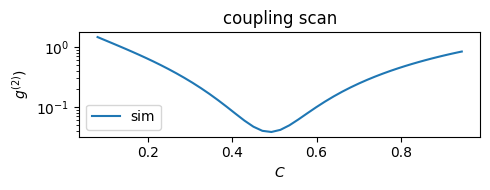

In [ ]:


U = 0.01
n_out_tar = 0.01
gamma = 0.

vec_g2 = [results[(U, ns, n_out_tar, gamma)]['g2'] for ns in n_photons]
ind = np.argmin(vec_g2)
g2_min = np.min(vec_g2)
ns_min = float(n_photons[ind])
res = results[(U, ns_min, n_out_tar, gamma)]
phase_min = res['phase']
coupling_min = res['coupling']

phase_scan = np.linspace(-0.04, 0.04, 50)
coupling_scan = np.linspace(-np.pi/6, np.pi/6)

# comparison with optimization

plt.figure(figsize=(5,2))
vec_g2_sim = []
for n_photon in n_photons:
    alpha_0 = 1j * res['phase'] * np.sqrt(n_photon) / np.sqrt(2)
    alpha, N, M = solve_ODE_AS_mode(J=res['coupling'], U_ns=U * n_photon, alpha_0=alpha_0, tlist=[0.,1.], gamma=gamma)

    g2 = get_g2(alpha[-1], N[-1], M[-1])
    vec_g2_sim.append(g2)

plt.loglog(n_photons, vec_g2_sim, label='sim')
plt.loglog(n_photons, vec_g2, label='optim')

plt.legend()
plt.xlabel(r"$n_S$")
plt.ylabel(r"$g^{(2)})$")
plt.title('comparison')
plt.tight_layout()
plt.show()

# phase scan

plt.figure(figsize=(5,2))
vec_g2_phase = []
for phase in phase_scan:
    alpha_0 = 1j * (phase + phase_min) * np.sqrt(ns_min) / np.sqrt(2)
    alpha, N, M = solve_ODE_AS_mode(J=res['coupling'], U_ns=U * ns_min, alpha_0=alpha_0, tlist=[0.,1.], gamma=gamma)

    g2 = get_g2(alpha[-1], N[-1], M[-1])
    vec_g2_phase.append(g2)

plt.semilogy((phase_scan + phase_min)/np.pi, vec_g2_phase, label='sim')
plt.legend()
plt.xlabel(r"$\varphi/\pi$")
plt.ylabel(r"$g^{(2)})$")
plt.title('Phase scan')
plt.tight_layout()
plt.show()

# scan coupling
plt.figure(figsize=(5,2))
vec_g2_coupling = []
for coupling in coupling_scan:
    alpha_0 = 1j * phase_min* np.sqrt(ns_min) / np.sqrt(2)
    alpha, N, M = solve_ODE_AS_mode(J=coupling + coupling_min, U_ns=U * ns_min, alpha_0=alpha_0, tlist=[0.,1.], gamma=gamma)

    g2 = get_g2(alpha[-1], N[-1], M[-1])
    vec_g2_coupling.append(g2)

plt.semilogy(np.sin(coupling_scan + coupling_min) ** 2, vec_g2_coupling, label='sim')
plt.legend()
plt.xlabel(r"$C$")
plt.ylabel(r"$g^{(2)})$")
plt.title('coupling scan')
plt.tight_layout()
plt.show()

# AS occupation check

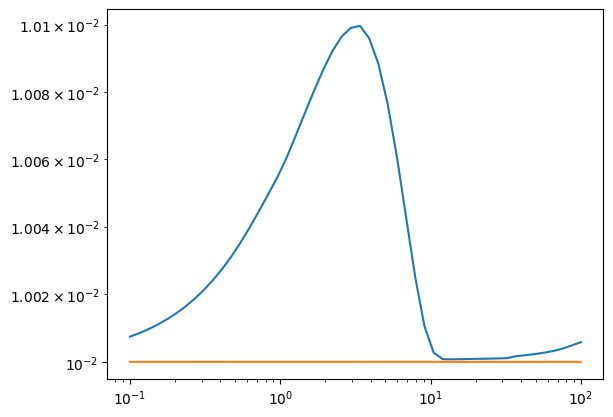

In [ ]:
U = 0.01
n_out_tar = 0.01
gamma = 0.

phases = np.array([results[(U, ns, n_out_tar, gamma)]['phase'] for ns in n_photons])
vec_alpha = np.array([results[(U, ns, n_out_tar, gamma)]['alpha'] for ns in n_photons])
vec_N = np.array([results[(U, ns, n_out_tar, gamma)]['N'] for ns in n_photons])

na_phase = 0.5 * phases ** 2 * n_photons
na_meas = np.abs(vec_alpha) ** 2 + vec_N

plt.loglog(n_photons, na_phase)
# plt.semilogy(vec_ns, vec_ns)
plt.loglog(n_photons, na_meas)

In [ ]:
np.argmax(phases)

np.int64(0)

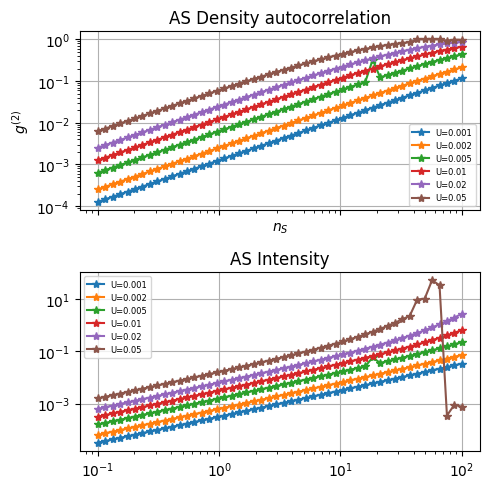

<Figure size 500x200 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

n_out_tar = None
gamma = 0.

fig, ax = plt.subplots(2,1, figsize=(5,5), sharex=True)
for U in Us[:-1]:
    dat_g2 = []
    for n_photon in n_photons:
        dat_g2.append(results[(U, n_photon, n_out_tar, gamma)]['g2'])

    ax[0].loglog(n_photons, dat_g2, "*-", label=f"U={U}")

#plt.ylim(0,0.3)
ax[0].grid(True)
ax[0].legend(fontsize=6)
ax[0].set_title("AS Density autocorrelation")
ax[0].set_ylabel(r"$g^{(2)}$")

plt.figure(figsize=(5,2))
for U in Us[:-1]:
    dat_n_out = []
    for n_photon in n_photons:
        n_out = np.abs(results[(U, n_photon, n_out_tar, gamma)]['alpha']) ** 2 \
            + np.abs(results[(U, n_photon, n_out_tar, gamma)]['N'])
        dat_n_out.append(n_out)

    ax[1].loglog(n_photons, dat_n_out, "*-", label=f"U={U}")

ax[1].grid(True)
ax[1].legend(fontsize=6)
ax[0].set_xlabel(r"$n_S$")
ax[1].set_title("AS Intensity")

fig.tight_layout()

In [ ]:
results[(Us[0],n_photons[0])]['g2']

np.complex128(0.19651278031228242+0j)